# Evaluate Unsupervised Machine Learning Classifiers on New, Unseen Data

### Imports

In [1]:
# General
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import os

# Image Analysis
from skimage.measure import label, regionprops

# Model and Data Preservation
import joblib
import json

### Inputs

In [2]:
# Set start time
start_time = time.time()

# Input the AFM scan dimensions in microns
width_micron=1.0
height_micron=1.0

# Specify the path to the input folder (location of all files/data)
'''
This is the location in which the trained ML classifiers, list of
features used in the training, scalers used in the training, and 
new processed AFM data are saved.
'''
input_folder = "."

# Specify the path to the output folder (location to store saved files)
'''
This is the location in which any outputs will be saved.
'''
output_folder = "."

# Specify the filename of the .pkl file of the trained Particle/Substrate ML classifier
'''
This is a .pkl file of the trained Particle/Substrate ML Classifier
saved in the input folder.
'''
model_1_filename = 'kmeans_classifier_particle_substrate.pkl'


# Specify the filename of the .pkl file of the trained Inner Particle Structure ML classifier
'''
This is a .pkl file of the trained Inner Particle Structure ML Classifier
saved in the input folder.
'''
model_2_filename = 'kmeans_classifier_inner_particle_structure.pkl'

# Specify the filename of the .pkl file of the scaler used for the trained Particle/Substrate ML classifier
'''
This is the .pkl file of the scaler used in the training of the
Particle/Substrate ML classifier
'''
scaler_1_filename = 'kmeans_scaler_particle_substrate.pkl'


# Specify the filename of the .pkl file of the scaler used for the trained Inner Particle Structure ML classifier
'''
This is the .pkl file of the scaler used in the training of the
Inner Particle Structure ML classifier
'''
scaler_2_filename = 'kmeans_scaler_inner_particle_structure.pkl'


# Specify the filename of the .json file of the features list used to train the saved classifiers
'''
This is a .json file of the list of features used to train the ML classifiers
'''
features_filename = 'kmeans_selected_features.json'


# Specify the filename of the .csv file of the new, unseen processed AFM data
'''
This is a .csv file containing the feature values for each
force-distance curve in the AFM scan of new, unseen data. 
Each row is a different force-distance 
curve and each column is a different feature value.
'''
data_new_filename = 'new_unseen_scan_1_feature_values.csv'


# Define font properties for all plots
font = {'size': 20, 'weight': 'normal'}
plt.rc('font', **font)

### Functions

In [3]:
# Define a function to plot classification plots
def plot_afm_classification(image_data, width_micron, height_micron, title = "AFM Image"):
    
    plt.figure(figsize=(10, 8))
    extent = [0, width_micron, 0, height_micron]  # [xmin, xmax, ymin, ymax]
    
    plt.imshow(image_data, cmap="gray", extent=extent)
    plt.xlabel("µm")
    plt.title(title)
    
    cbar = plt.colorbar(label="Classification")
    cbar.set_ticks([0, 1])
    
    plt.show()

### Import data for each  force-distance curve

In [4]:
# Read the .csv file into a DataFrame
file_path_data_new = os.path.join(input_folder, data_new_filename)
df_all_data_new = pd.read_csv(file_path_data_new)

### Import Feature List to Use

In [5]:
# Load the selected features
features_file_path = os.path.join(input_folder, features_filename)
with open(features_file_path, 'r') as f:
    selected_features = json.load(f)
    
# Display feature list information
print("Features loaded successfully as list:")
print(selected_features)
print('Number of selected features:', len(selected_features))

Features loaded successfully as list:
['Deformation from 2% to 5% of max force', 'Deformation from 2% to 25% of max force', 'Deformation from 2% to 50% of max force', 'Deformation from 2% to 75% of max force', 'Deformation from 2% to 100% of max force', 'Deformation from 5% to 25% of max force', 'Deformation from 5% to 50% of max force', 'Deformation from 5% to 75% of max force', 'Deformation from 5% to 100% of max force', 'Deformation from 25% to 50% of max force', 'Deformation from 25% to 75% of max force', 'Deformation from 25% to 100% of max force', 'Deformation from 50% to 75% of max force', 'Deformation from 50% to 100% of max force', 'Deformation from 75% to 100% of max force', 'Stiffness at max force', "Young's modulus (10 nm indentation)", "Young's modulus (entire deformation)", 'Recovery from 5% to 2% of max force', 'Recovery from 25% to 2% of max force', 'Recovery from 50% to 2% of max force', 'Recovery from 75% to 2% of max force', 'Recovery from 100% to 2% of max force', '

### Create a dataframe of selected feature values for each force-distance curve

In [6]:
# Check that all required features are present
missing_features = [f for f in selected_features if f not in df_all_data_new.columns]
if missing_features:
    raise ValueError(f"Missing required features in new data: {missing_features}")

# Load the new data
X_new = df_all_data_new.loc[:, selected_features]

### Load the Particle/Substrate ML Classifier and Scaler

In [7]:
# Load the trained unsupervised model
model_1_file_path = os.path.join(input_folder, model_1_filename)
kmeans_classifier_particle_substrate = joblib.load(model_1_file_path)
print("Particle/Substrate ML Classifier loaded from:", model_1_file_path)

# load the unsupervised particle/substrate scaler
scaler_1_file_path = os.path.join(input_folder, scaler_1_filename)
scaler_1 = joblib.load(scaler_1_file_path)
print("Particle/Substrate Scaler loaded from:", scaler_1_file_path)

Particle/Substrate ML Classifier loaded from: .\kmeans_classifier_particle_substrate.pkl
Particle/Substrate Scaler loaded from: .\kmeans_scaler_particle_substrate.pkl


### Evaluate Particle Substrate ML Classifier on New Data

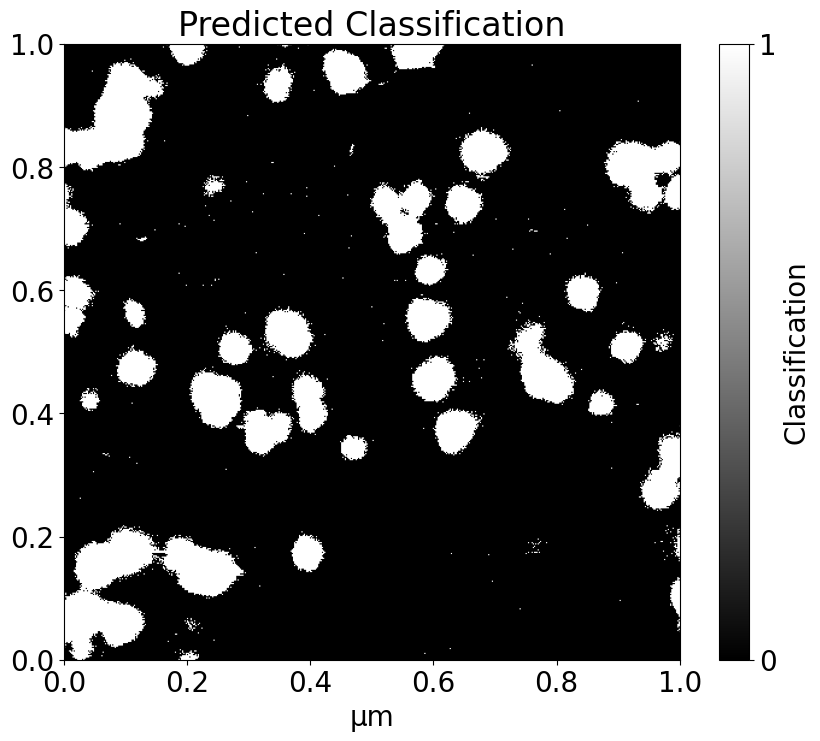

In [8]:
# Scale the data using the loaded particle/substrate scaler
X_new_scaled = scaler_1.transform(X_new)

# Predict classification on new data using the loaded model
y_pred_new = kmeans_classifier_particle_substrate.predict(X_new_scaled)

# Define the square image size
image_size = int(math.sqrt(len(y_pred_new))) # assuming a square image
# Reshape the predicted output labels into a 512x512 image
image_pred_new = y_pred_new.reshape(image_size, image_size)
# Plot the image
plot_afm_classification(
    image_pred_new,
    width_micron,
    height_micron,
    title="Predicted Classification"
)

### Remove small clusters from predicted classification of particle/substrate classifier

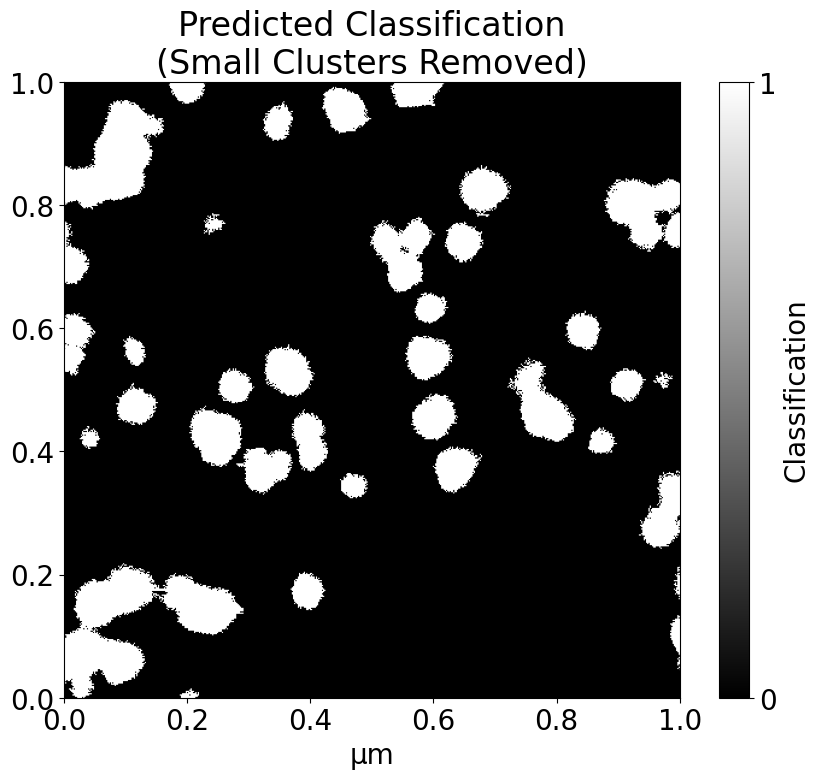

Total number of pixels with value 1 before changes: 38368
Total number of pixels whose values were changed: 556
Percent of PG pixels changed: 1.4491242702251876%


In [9]:
# Set the maximum number of pixels in a cluster to remove
threshold = 35

# Define the image of interest
image = image_pred_new

# Create a new image with the same dimensions as the original image
new_image = np.copy(image)

# Label connected components in the image
labeled_image = label(new_image)

# Get properties of each connected component
regions = regionprops(labeled_image)

# Iterate through each region and examine area of region
# If region area is less than threshold change classification value to 0
for region in regions:
    if region.area < threshold and new_image[region.coords[0][0], region.coords[0][1]] == 1:
        for coord in region.coords:
            new_image[coord[0], coord[1]] = 0

# Plot the new image
plot_afm_classification(
    new_image,
    width_micron,
    height_micron,
    title="Predicted Classification\n(Small Clusters Removed)"
)

# Calculate the total number of pixels with value 1 in the original image
total_white_pixels = np.sum(image == 1)

# Calculate the total number of changed pixels
changed_pixels = np.sum(image != new_image)

# Calculate the percent of changed pixels in terms of all PG pixels
changed_pixels_percent = 100*changed_pixels/total_white_pixels

# Print the result
print(f"Total number of pixels with value 1 before changes: {total_white_pixels}")
print(f"Total number of pixels whose values were changed: {changed_pixels}")
print(f"Percent of PG pixels changed: {changed_pixels_percent}%")

### Load Inner Particle Structure ML Classifier and Scaler

In [10]:
# Load the trained Inner Particle Structure ML Classifier
model_2_file_path = os.path.join(input_folder, model_2_filename)
kmeans_classifier_inner_particle_structure = joblib.load(model_2_file_path)
print("Model loaded from:", model_2_file_path)

# load the unsupervised Inner Particle Structure scaler
scaler_2_file_path = os.path.join(input_folder, scaler_2_filename)
scaler_2 = joblib.load(scaler_2_file_path)
print("Inner Particle Structure Scaler loaded from:", scaler_2_file_path)

Model loaded from: .\kmeans_classifier_inner_particle_structure.pkl
Inner Particle Structure Scaler loaded from: .\kmeans_scaler_inner_particle_structure.pkl


### Evaluate Inner Particle Structure ML Classifier on New Data (within particle regions determined via the particle/substrate ML classifier)

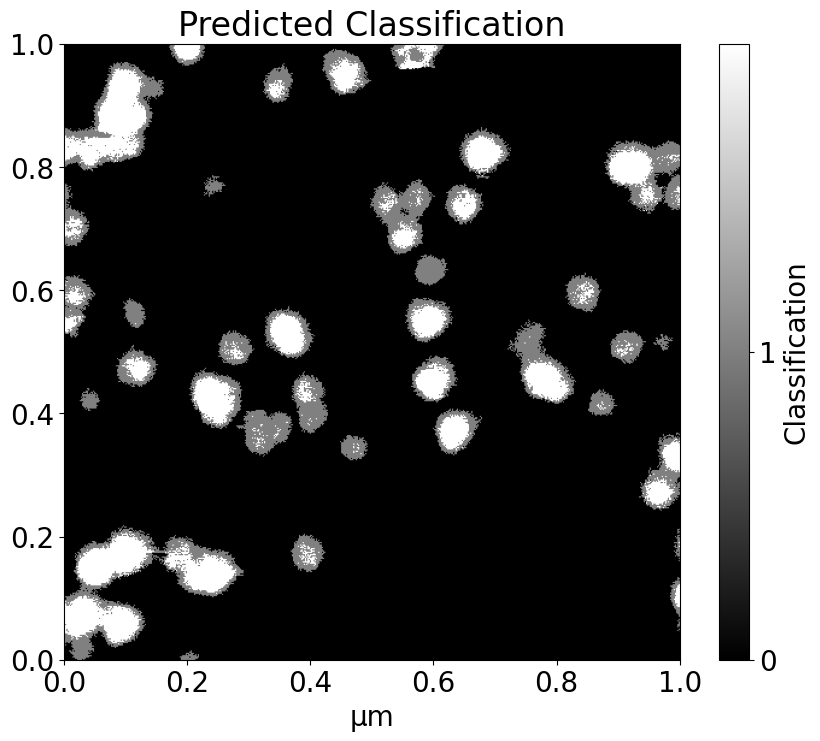

Total Run Time =  2.224050760269165 seconds


In [11]:
# Take output from particle/substrate classifier
filtered_new = new_image.flatten()
# Create a mask of each pixel in the particle region determined via the particle/substrate classifier
mask_new = (filtered_new != 0)
# Use mask to filter data to include only data manually labelled as corresponding to particles
X_new_filtered = X_new[mask_new]


#----- Plot the predicted classification -----#

# Scale the data using the trained Inner Particle Structure scaler
X_new_filtered_scaled = scaler_2.transform(X_new_filtered)
# Predict classification using the trained inner particle structure ML classifier
y_pred_new_filtered = kmeans_classifier_inner_particle_structure.predict(X_new_filtered_scaled) 
# Update the predicted regions to include the results of the second classifier
y_pred_new_filtered = y_pred_new_filtered + 1 #change outer particle region to values of 1 and inner region to values of 2
y_pred_new_filtered_combined = np.copy(filtered_new) # copy the output from the first classifier
y_pred_new_filtered_combined[mask_new] = y_pred_new_filtered # update the pixels according to the second clssifier
# Define image size
image_size = int(math.sqrt(len(X_new)))
# Reshape the predicted classification data
image_pred_new_filtered = y_pred_new_filtered_combined.reshape(image_size, image_size)
# Plot the image
plot_afm_classification(
    image_pred_new_filtered,
    width_micron,
    height_micron,
    title="Predicted Classification"
)

# Calculate the total run time
end_time = time.time()
elapsed_time = end_time - start_time

print("Total Run Time = ", elapsed_time, "seconds")